In [50]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Any, Literal, Sequence
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize_scalar

from PFC_NP_analysis.utils.config import Params, set_params
from PFC_NP_analysis.utils.loadData import load_pickle, extract_used_data


RuleName = Literal["pattern", "position"]
ModelName = Literal["local", "global"]


@dataclass(frozen=True)
class BehaviorModelConfig:
    """
    行为模型配置。

    epsilon_tail_trials:
        用 switch 前最后多少个 trial 估计 epsilon。

        None:
            使用全部 switch 前 trial。适合整个 switch 前区间都已经稳定的情况。

        例如 30:
            仅使用 switch 前最后 30 个 trial。
            如果 switch 前区间包含一部分学习过程，推荐设置为 20~50。

    alpha_bounds:
        Local/Global 模型学习率搜索范围。

    epsilon_bounds:
        防止 epsilon 精确等于 0 或过高。
    """

    epsilon_tail_trials: int | None = None

    alpha_bounds: tuple[float, float] = (1e-6, 1.0)
    epsilon_bounds: tuple[float, float] = (1e-5, 0.30)

    recursive_search: bool = True

In [51]:
def _to_scalar_int(value: Any) -> int:
    """将 NumPy/MATLAB 标量转换为 Python int。"""
    array = np.asarray(value)

    if array.size != 1:
        raise ValueError(
            f"Expected scalar trial index, got shape={array.shape}."
        )

    return int(array.item())


def load_mouse_data(
    file_path: str | Path,
    *,
    is_pretrain: bool = False,
) -> dict:
    """
    读取单只小鼠的 pickle 文件，并调用已有 extract_used_data()。

    假设文件内容是包含以下键的原始字典：
        simple_firing
        zones
        pos_lick_type
        pos_reward_type
        type_index
    """
    file_path = Path(file_path)

    with file_path.open("rb") as file:
        raw_data = pickle.load(file)

    if not isinstance(raw_data, dict):
        raise TypeError(
            f"{file_path} does not contain a dictionary."
        )

    return extract_used_data(
        raw_data,
        is_pretrain=is_pretrain,
    )


def build_trials(
    data: dict,
    params: Params,
) -> list[dict]:
    """
    将 object-grid 数据整理成按真实时间排序的 trial list。

    couple_* trial 会被完全排除，不进入后续建模。
    """
    n_trial_types, n_behavior_types = data["shape"]

    if n_trial_types > len(params.tt):
        raise ValueError(
            f"Data has {n_trial_types} trial types, "
            f"but params.tt only has {len(params.tt)} entries."
        )

    if n_behavior_types > len(params.bt):
        raise ValueError(
            f"Data has {n_behavior_types} behavior types, "
            f"but params.bt only has {len(params.bt)} entries."
        )

    trials: list[dict] = []

    for trial_type_id in range(n_trial_types):
        trial_type = params.tt[trial_type_id]

        # 当前分析不包含 couple rule。
        if trial_type.startswith("couple_"):
            continue

        if not (
            trial_type.startswith("pattern_")
            or trial_type.startswith("position_")
        ):
            continue

        for behavior_type_id in range(n_behavior_types):
            firing = data["simple_firing"][
                trial_type_id,
                behavior_type_id,
            ]

            if firing is None:
                continue

            n_trials = firing.shape[1]

            for trial_in_type in range(n_trials):
                trials.append(
                    {
                        "trial_type": trial_type,
                        "behavior_type": params.bt[
                            behavior_type_id
                        ],
                        "index": _to_scalar_int(
                            data["type_index"][
                                trial_type_id,
                                behavior_type_id,
                            ][trial_in_type]
                        ),
                        "lick": data["pos_lick_type"][
                            trial_type_id,
                            behavior_type_id,
                        ][trial_in_type],
                        "reward": data["pos_reward_type"][
                            trial_type_id,
                            behavior_type_id,
                        ][trial_in_type],
                    }
                )

    trials.sort(key=lambda trial: trial["index"])

    if not trials:
        raise ValueError(
            "No pattern/position trials remain after excluding couple trials."
        )

    return trials

In [52]:
def _flatten_numeric(value: Any) -> np.ndarray:
    """递归展开 MATLAB/object-array 风格的数据。"""
    output: list[float] = []

    def collect(item: Any) -> None:
        if item is None:
            return

        if isinstance(item, np.ndarray):
            for sub_item in item.ravel():
                collect(sub_item)
            return

        if isinstance(item, (list, tuple)):
            for sub_item in item:
                collect(sub_item)
            return

        try:
            number = float(item)
        except (TypeError, ValueError):
            return

        if np.isfinite(number):
            output.append(number)

    collect(value)
    return np.asarray(output, dtype=float)


def _events_to_zones(
    values: Any,
    zones: np.ndarray,
) -> np.ndarray:
    """
    将连续 lick/reward 位置转换为 5 个二元值。

    同一个 zone 内 lick 多次仍然只记为 action=1。
    """
    positions = _flatten_numeric(values)
    binary = np.zeros(5, dtype=int)

    for zone_id, (start, end) in enumerate(zones):
        if np.any(
            (positions >= start)
            & (positions <= end)
        ):
            binary[zone_id] = 1

    return binary


def _parse_rule(trial_type: str) -> RuleName:
    if trial_type.startswith("pattern_"):
        return "pattern"

    if trial_type.startswith("position_"):
        return "position"

    raise ValueError(
        f"Unsupported trial type: {trial_type!r}."
    )


def _parse_trial_code(trial_type: str) -> str:
    code = trial_type.split("_", maxsplit=1)[1]

    if len(code) != 3 or sorted(code) != ["A", "B", "C"]:
        raise ValueError(
            f"Invalid trial code: {trial_type!r}."
        )

    return code


def _cue_sequence(code: str) -> tuple[str, ...]:
    """
    将 CAB/CBA/... 转换为跑道上 5 个位置的 cue 序列。
    """
    c_order = code.index("C")

    if c_order == 0:
        return (
            "C",
            code[1],
            "blank",
            code[2],
            "blank",
        )

    if c_order == 1:
        return (
            "blank",
            code[0],
            "C",
            code[2],
            "blank",
        )

    return (
        "blank",
        code[0],
        "blank",
        code[1],
        "C",
    )


def build_decision_table(
    trials: Sequence[dict],
    zones: np.ndarray,
) -> pd.DataFrame:
    """
    将每个 trial 展开为 5 个按空间顺序排列的二元决策。

    支持一次或多次 pattern <-> position 转换。

    重要字段
    --------
    rule_block_id:
        初始规则 block 为 0。
        第一次转换后的 block 为 1。
        第二次转换后的 block 为 2。
        依此类推。

    switch_number:
        与 rule_block_id 相同。
        0 表示第一次转换之前。

    is_post_switch:
        是否位于第一次转换之后。

    is_switch_trial:
        是否为某次转换后新规则的第一个 trial。
    """
    zones = np.asarray(zones, dtype=float)

    if zones.shape != (5, 2):
        raise ValueError(
            f"zones must have shape (5, 2), got {zones.shape}."
        )

    rows: list[dict] = []
    trial_rules: list[str] = []

    for trial_id, trial in enumerate(trials):
        trial_type = str(trial["trial_type"])
        task_rule = _parse_rule(trial_type)
        trial_code = _parse_trial_code(trial_type)
        cues = _cue_sequence(trial_code)

        actions = _events_to_zones(
            trial["lick"],
            zones,
        )

        rewards = _events_to_zones(
            trial["reward"],
            zones,
        )

        c_position = cues.index("C")
        trial_rules.append(task_rule)

        for step_index in range(5):
            pattern_target = int(
                step_index == c_position
            )

            position_target = int(
                step_index == 2
            )

            true_target = (
                pattern_target
                if task_rule == "pattern"
                else position_target
            )

            rows.append(
                {
                    "trial_id": trial_id,
                    "original_index": trial["index"],
                    "trial_type": trial_type,
                    "behavior_type": trial["behavior_type"],
                    "task_rule": task_rule,
                    "trial_code": trial_code,
                    "step_index": step_index,
                    "position_number": step_index + 1,
                    "cue_identity": cues[step_index],
                    "state_key": (
                        step_index,
                        cues[step_index],
                    ),
                    "action": int(actions[step_index]),
                    "reward": int(rewards[step_index]),
                    "pattern_target": pattern_target,
                    "position_target": position_target,
                    "true_target": int(true_target),
                    "is_diagnostic": bool(
                        pattern_target != position_target
                    ),
                }
            )

    decision_df = pd.DataFrame(rows)

    if decision_df.empty:
        raise ValueError("No decisions were generated.")

    # ---------------------------------------------------------
    # 检测所有 pattern <-> position 转换
    # ---------------------------------------------------------
    switch_records: list[dict] = []

    rule_block_ids = np.zeros(
        len(trial_rules),
        dtype=int,
    )

    current_block_id = 0

    for trial_id in range(1, len(trial_rules)):
        previous_rule = trial_rules[trial_id - 1]
        current_rule = trial_rules[trial_id]

        if current_rule != previous_rule:
            current_block_id += 1

            switch_records.append(
                {
                    "switch_number": current_block_id,
                    "switch_trial_id": trial_id,
                    "old_rule": previous_rule,
                    "new_rule": current_rule,
                    "switch_direction": (
                        f"{previous_rule}_to_{current_rule}"
                    ),
                }
            )

        rule_block_ids[trial_id] = current_block_id

    if not switch_records:
        raise ValueError(
            "No pattern-position switch was found after "
            "excluding couple trials."
        )

    switch_df = pd.DataFrame(switch_records)
    switch_trial_ids = switch_df[
        "switch_trial_id"
    ].to_numpy(dtype=int)

    # ---------------------------------------------------------
    # State ID
    # ---------------------------------------------------------
    unique_states = list(
        dict.fromkeys(decision_df["state_key"])
    )

    state_to_id = {
        state: state_id
        for state_id, state in enumerate(unique_states)
    }

    decision_df["state_id"] = (
        decision_df["state_key"]
        .map(state_to_id)
        .astype(int)
    )

    # ---------------------------------------------------------
    # 把 trial-level block 信息映射到每个 decision
    # ---------------------------------------------------------
    trial_to_block = {
        trial_id: int(block_id)
        for trial_id, block_id in enumerate(rule_block_ids)
    }

    decision_df["rule_block_id"] = (
        decision_df["trial_id"]
        .map(trial_to_block)
        .astype(int)
    )

    decision_df["switch_number"] = (
        decision_df["rule_block_id"]
    )

    first_switch_trial_id = int(
        switch_trial_ids[0]
    )

    decision_df["first_switch_trial_id"] = (
        first_switch_trial_id
    )

    decision_df["is_post_switch"] = (
        decision_df["trial_id"]
        >= first_switch_trial_id
    )

    decision_df["is_switch_trial"] = (
        decision_df["trial_id"]
        .isin(switch_trial_ids)
    )

    initial_rule = trial_rules[0]

    decision_df["initial_rule"] = initial_rule
    decision_df["n_switches"] = len(switch_records)

    block_direction = {
        0: "initial",
    }

    for record in switch_records:
        block_direction[
            record["switch_number"]
        ] = record["switch_direction"]

    decision_df["block_direction"] = (
        decision_df["rule_block_id"]
        .map(block_direction)
    )

    # attrs 仅用于方便读取，核心信息也都保留在列中。
    decision_df.attrs["initial_rule"] = initial_rule
    decision_df.attrs["first_switch_trial_id"] = (
        first_switch_trial_id
    )
    decision_df.attrs["switches"] = switch_records
    decision_df.attrs["state_to_id"] = state_to_id

    return decision_df

In [53]:
def _rule_probability(
    rule: RuleName,
    pattern_target: int,
    position_target: int,
    epsilon: float,
) -> float:
    """给定规则时，在当前 state 的专家 lick 概率。"""
    if rule == "pattern":
        target = pattern_target
    elif rule == "position":
        target = position_target
    else:
        raise ValueError(f"Unknown rule: {rule!r}.")

    return (
        1.0 - epsilon
        if target == 1
        else epsilon
    )


def _feedback_evidence(
    action: int,
    reward: int,
    pattern_target: int,
    position_target: int,
) -> RuleName | None:
    """
    根据当前 lick outcome 推断反馈支持哪条规则。

    不更新的情况：
        no lick；
        ACB/BCA 等 non-diagnostic step；
        两规则预测相同。
    """
    if action == 0:
        return None

    if pattern_target == position_target:
        return None

    if pattern_target == 1:
        return "pattern" if reward == 1 else "position"

    return "position" if reward == 1 else "pattern"


def run_model(
    decision_df: pd.DataFrame,
    *,
    model: ModelName,
    alpha: float,
    epsilon: float,
) -> pd.DataFrame:
    """
    从第一次 switch 后开始运行 Local 或 Global 模型。

    多次转换处理
    ------------
    模型不会在后续 switch 时重置：

    Local:
        保留所有已经更新过的 state value，并继续反向更新。

    Global:
        保留当前 rule belief，并根据新反馈继续向另一规则更新。

    每个 decision 输出正数 NLL contribution：
        nll = -log P(observed action)
    """
    if not 0.0 <= alpha <= 1.0:
        raise ValueError(
            f"alpha must be in [0, 1], got {alpha}."
        )

    if not 0.0 < epsilon < 0.5:
        raise ValueError(
            f"epsilon must be in (0, 0.5), got {epsilon}."
        )

    initial_rule = str(
        decision_df["initial_rule"].iloc[0]
    )

    first_switch_trial_id = int(
        decision_df["first_switch_trial_id"].iloc[0]
    )

    post_df = (
        decision_df[
            decision_df["trial_id"]
            >= first_switch_trial_id
        ]
        .copy()
        .reset_index(drop=True)
    )

    if post_df.empty:
        raise ValueError(
            "No decisions were found after the first switch."
        )

    # ---------------------------------------------------------
    # 初始化模型状态
    # ---------------------------------------------------------
    if model == "local":
        n_states = (
            int(decision_df["state_id"].max())
            + 1
        )

        state_values = np.empty(
            n_states,
            dtype=float,
        )

        for state_id, state_rows in decision_df.groupby(
            "state_id",
            sort=False,
        ):
            row = state_rows.iloc[0]

            state_values[int(state_id)] = (
                _rule_probability(
                    initial_rule,
                    int(row["pattern_target"]),
                    int(row["position_target"]),
                    epsilon,
                )
            )

    elif model == "global":
        belief_pattern = (
            1.0
            if initial_rule == "pattern"
            else 0.0
        )

    else:
        raise ValueError(
            f"Unknown model: {model!r}."
        )

    history: list[dict] = []

    # ---------------------------------------------------------
    # 连续运行所有 switch 后 decision
    # ---------------------------------------------------------
    for row in post_df.itertuples(index=False):
        pattern_probability = _rule_probability(
            "pattern",
            int(row.pattern_target),
            int(row.position_target),
            epsilon,
        )

        position_probability = _rule_probability(
            "position",
            int(row.pattern_target),
            int(row.position_target),
            epsilon,
        )

        if model == "local":
            p_lick = float(
                state_values[int(row.state_id)]
            )

            latent_before = p_lick

        else:
            latent_before = float(
                belief_pattern
            )

            p_lick = (
                belief_pattern
                * pattern_probability
                + (1.0 - belief_pattern)
                * position_probability
            )

        p_lick = float(
            np.clip(
                p_lick,
                1e-12,
                1.0 - 1e-12,
            )
        )

        action = int(row.action)
        reward = int(row.reward)

        observed_probability = (
            p_lick
            if action == 1
            else 1.0 - p_lick
        )

        nll_contribution = -float(
            np.log(observed_probability)
        )

        evidence_rule = _feedback_evidence(
            action,
            reward,
            int(row.pattern_target),
            int(row.position_target),
        )

        update_occurred = (
            evidence_rule is not None
        )

        # -----------------------------------------------------
        # Local：只更新当前 state
        # -----------------------------------------------------
        if model == "local":
            state_id = int(row.state_id)

            if evidence_rule is not None:
                target_value = (
                    1.0 - epsilon
                    if reward == 1
                    else epsilon
                )

                state_values[state_id] = (
                    (1.0 - alpha)
                    * state_values[state_id]
                    + alpha
                    * target_value
                )

            latent_after = float(
                state_values[state_id]
            )

        # -----------------------------------------------------
        # Global：更新共享 rule belief
        # -----------------------------------------------------
        else:
            if evidence_rule == "pattern":
                belief_pattern = (
                    (1.0 - alpha)
                    * belief_pattern
                    + alpha
                )

            elif evidence_rule == "position":
                belief_pattern = (
                    (1.0 - alpha)
                    * belief_pattern
                )

            latent_after = float(
                belief_pattern
            )

        history.append(
            {
                "trial_id": int(row.trial_id),
                "step_index": int(row.step_index),
                "state_id": int(row.state_id),
                "state_key": row.state_key,
                "task_rule": row.task_rule,
                "rule_block_id": int(
                    row.rule_block_id
                ),
                "switch_number": int(
                    row.switch_number
                ),
                "block_direction": (
                    row.block_direction
                ),
                "is_switch_trial": bool(
                    row.is_switch_trial
                ),
                "action": action,
                "reward": reward,
                "is_diagnostic": bool(
                    row.is_diagnostic
                ),
                "p_lick": p_lick,
                "nll": nll_contribution,
                "evidence_rule": evidence_rule,
                "update_occurred": (
                    update_occurred
                ),
                "latent_before": latent_before,
                "latent_after": latent_after,
            }
        )

    return pd.DataFrame(history)

In [54]:
def estimate_pre_switch_epsilon(
    decision_df: pd.DataFrame,
    config: BehaviorModelConfig,
) -> tuple[float, int]:
    """
    用 switch 前稳定行为估计共享 epsilon。

    对于每个位置：
        真实规则要求 lick，但小鼠没舔 -> error
        真实规则要求 no lick，但小鼠舔 -> error

    在对称 exploration 假设下：
        epsilon_MLE = error decisions / all decisions
    """
    pre_df = decision_df[
        ~decision_df["is_post_switch"]
    ].copy()

    if pre_df.empty:
        raise ValueError(
            "No pre-switch decisions available for epsilon estimation."
        )

    if config.epsilon_tail_trials is not None:
        trial_ids = np.sort(
            pre_df["trial_id"].unique()
        )

        selected_ids = trial_ids[
            -config.epsilon_tail_trials:
        ]

        pre_df = pre_df[
            pre_df["trial_id"].isin(selected_ids)
        ]

    errors = (
        pre_df["action"].to_numpy(dtype=int)
        != pre_df["true_target"].to_numpy(dtype=int)
    )

    epsilon = float(errors.mean())

    epsilon = float(
        np.clip(
            epsilon,
            config.epsilon_bounds[0],
            config.epsilon_bounds[1],
        )
    )

    return epsilon, len(pre_df)


def fit_model_alpha(
    decision_df: pd.DataFrame,
    *,
    model: ModelName,
    epsilon: float,
    config: BehaviorModelConfig,
) -> dict:
    """
    固定 epsilon，通过最小化 NLL 拟合 alpha。

    模型从第一次 switch 开始连续运行，
    包含第一次、第二次及后续所有转换。
    """

    def objective(alpha: float) -> float:
        history = run_model(
            decision_df,
            model=model,
            alpha=float(alpha),
            epsilon=epsilon,
        )

        return float(
            history["nll"].sum()
        )

    optimization = minimize_scalar(
        objective,
        method="bounded",
        bounds=config.alpha_bounds,
        options={
            "xatol": 1e-7,
        },
    )

    if not optimization.success:
        raise RuntimeError(
            f"{model} optimization failed: "
            f"{optimization.message}"
        )

    alpha = float(optimization.x)

    history = run_model(
        decision_df,
        model=model,
        alpha=alpha,
        epsilon=epsilon,
    )

    diagnostic_mask = history[
        "is_diagnostic"
    ].to_numpy(dtype=bool)

    post_nll = float(
        history["nll"].sum()
    )

    post_diagnostic_nll = float(
        history.loc[
            diagnostic_mask,
            "nll",
        ].sum()
    )

    n_post = len(history)

    n_diagnostic = int(
        diagnostic_mask.sum()
    )

    # ---------------------------------------------------------
    # 分别汇总每一次 switch 后的规则 block
    # ---------------------------------------------------------
    per_switch_rows: list[dict] = []

    for switch_number, block in history.groupby(
        "switch_number",
        sort=True,
    ):
        if int(switch_number) == 0:
            continue

        block_diagnostic = block[
            block["is_diagnostic"]
        ]

        per_switch_rows.append(
            {
                "model": model,
                "switch_number": int(
                    switch_number
                ),
                "switch_direction": str(
                    block[
                        "block_direction"
                    ].iloc[0]
                ),
                "n_decisions": len(block),
                "n_diagnostic_decisions": len(
                    block_diagnostic
                ),
                "nll": float(
                    block["nll"].sum()
                ),
                "diagnostic_nll": float(
                    block_diagnostic[
                        "nll"
                    ].sum()
                ),
                "nll_per_decision": float(
                    block["nll"].mean()
                ),
                "diagnostic_nll_per_decision": (
                    float(
                        block_diagnostic[
                            "nll"
                        ].mean()
                    )
                    if not block_diagnostic.empty
                    else np.nan
                ),
            }
        )

    return {
        "model": model,
        "alpha": alpha,
        "epsilon": epsilon,

        "post_nll": post_nll,
        "post_diagnostic_nll": (
            post_diagnostic_nll
        ),

        "n_post_decisions": n_post,
        "n_post_diagnostic_decisions": (
            n_diagnostic
        ),

        "post_nll_per_decision": (
            post_nll / n_post
        ),

        "post_diagnostic_nll_per_decision": (
            post_diagnostic_nll
            / n_diagnostic
            if n_diagnostic > 0
            else np.nan
        ),

        "optimization_success": True,
        "history": history,
        "per_switch": pd.DataFrame(
            per_switch_rows
        ),
    }


def fit_one_mouse(
    decision_df: pd.DataFrame,
    config: BehaviorModelConfig,
) -> dict:
    """
    拟合一只小鼠的 Local/Global 模型。

    epsilon:
        使用第一次 switch 前的稳定行为统一估计。

    alpha:
        使用第一次 switch 后的全部行为拟合。
        如果有第二次 switch，模型连续运行，不重置。

    Delta NLL:
        Local NLL - Global NLL

        > 0:
            Global 更好。

        < 0:
            Local 更好。
    """
    epsilon, n_epsilon_decisions = (
        estimate_pre_switch_epsilon(
            decision_df,
            config,
        )
    )

    local_fit = fit_model_alpha(
        decision_df,
        model="local",
        epsilon=epsilon,
        config=config,
    )

    global_fit = fit_model_alpha(
        decision_df,
        model="global",
        epsilon=epsilon,
        config=config,
    )

    switch_records = (
        decision_df.attrs.get(
            "switches",
            [],
        )
    )

    switch_directions = " | ".join(
        record["switch_direction"]
        for record in switch_records
    )

    n_trials = int(
        decision_df["trial_id"].nunique()
    )

    n_pre_trials = int(
        decision_df.loc[
            ~decision_df["is_post_switch"],
            "trial_id",
        ].nunique()
    )

    n_post_trials = int(
        decision_df.loc[
            decision_df["is_post_switch"],
            "trial_id",
        ].nunique()
    )

    # ---------------------------------------------------------
    # 合并每次 switch 的 Local/Global NLL
    # ---------------------------------------------------------
    local_switch = (
        local_fit["per_switch"]
        .add_prefix("local_")
        .rename(
            columns={
                "local_switch_number": (
                    "switch_number"
                ),
                "local_switch_direction": (
                    "switch_direction"
                ),
            }
        )
    )

    global_switch = (
        global_fit["per_switch"]
        .add_prefix("global_")
        .rename(
            columns={
                "global_switch_number": (
                    "switch_number"
                ),
                "global_switch_direction": (
                    "switch_direction"
                ),
            }
        )
    )

    per_switch = local_switch.merge(
        global_switch,
        on=[
            "switch_number",
            "switch_direction",
        ],
        how="outer",
    )

    if not per_switch.empty:
        per_switch[
            "delta_nll_local_minus_global"
        ] = (
            per_switch["local_nll"]
            - per_switch["global_nll"]
        )

        per_switch[
            "delta_diagnostic_nll_local_minus_global"
        ] = (
            per_switch["local_diagnostic_nll"]
            - per_switch["global_diagnostic_nll"]
        )

    return {
        "n_switches": len(switch_records),
        "switch_directions": switch_directions,
        "first_switch_trial_id": int(
            decision_df[
                "first_switch_trial_id"
            ].iloc[0]
        ),

        "initial_rule": str(
            decision_df["initial_rule"].iloc[0]
        ),

        "n_trials": n_trials,
        "n_pre_trials": n_pre_trials,
        "n_post_trials": n_post_trials,
        "n_epsilon_decisions": (
            n_epsilon_decisions
        ),

        "epsilon": epsilon,
        "local_alpha": local_fit["alpha"],
        "global_alpha": global_fit["alpha"],

        "local_post_nll": (
            local_fit["post_nll"]
        ),
        "global_post_nll": (
            global_fit["post_nll"]
        ),

        "local_post_diagnostic_nll": (
            local_fit[
                "post_diagnostic_nll"
            ]
        ),
        "global_post_diagnostic_nll": (
            global_fit[
                "post_diagnostic_nll"
            ]
        ),

        "local_post_nll_per_decision": (
            local_fit[
                "post_nll_per_decision"
            ]
        ),
        "global_post_nll_per_decision": (
            global_fit[
                "post_nll_per_decision"
            ]
        ),

        "local_post_diagnostic_nll_per_decision": (
            local_fit[
                "post_diagnostic_nll_per_decision"
            ]
        ),
        "global_post_diagnostic_nll_per_decision": (
            global_fit[
                "post_diagnostic_nll_per_decision"
            ]
        ),

        # 正值表示 Global 更好
        "delta_nll_local_minus_global": (
            local_fit["post_nll"]
            - global_fit["post_nll"]
        ),

        "delta_diagnostic_nll_local_minus_global": (
            local_fit[
                "post_diagnostic_nll"
            ]
            - global_fit[
                "post_diagnostic_nll"
            ]
        ),

        "delta_diagnostic_nll_per_decision": (
            local_fit[
                "post_diagnostic_nll_per_decision"
            ]
            - global_fit[
                "post_diagnostic_nll_per_decision"
            ]
        ),

        "n_post_decisions": (
            local_fit["n_post_decisions"]
        ),

        "n_post_diagnostic_decisions": (
            local_fit[
                "n_post_diagnostic_decisions"
            ]
        ),

        "local_optimization_success": (
            local_fit[
                "optimization_success"
            ]
        ),

        "global_optimization_success": (
            global_fit[
                "optimization_success"
            ]
        ),

        "local_history": local_fit["history"],
        "global_history": global_fit["history"],
        "per_switch": per_switch,
    }

In [55]:
def analyze_behavior_folder(
    folder_path: str | Path,
    params: Params,
    *,
    config: BehaviorModelConfig | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, dict]]:
    """
    批量拟合文件夹内所有小鼠。

    Returns
    -------
    results_df:
        每行一只小鼠的参数与 LL。

    errors_df:
        无法分析的文件及错误原因。

    details:
        每只鼠的 decision table 和完整 model history。
    """
    if config is None:
        config = BehaviorModelConfig()

    folder_path = Path(folder_path).expanduser().resolve()

    if not folder_path.exists():
        raise FileNotFoundError(
            f"Folder does not exist: {folder_path}"
        )

    if config.recursive_search:
        files = sorted(
            list(folder_path.rglob("*.pkl"))
            + list(folder_path.rglob("*.pickle"))
        )
    else:
        files = sorted(
            list(folder_path.glob("*.pkl"))
            + list(folder_path.glob("*.pickle"))
        )

    if not files:
        raise FileNotFoundError(
            f"No .pkl/.pickle files found under {folder_path}."
        )

    result_rows: list[dict] = []
    error_rows: list[dict] = []
    details: dict[str, dict] = {}

    for file_path in files:
        mouse_id = file_path.stem

        try:
            data = load_pickle(file_path)
            data = extract_used_data(data)

            trials = build_trials(
                data,
                params,
            )

            decision_df = build_decision_table(
                trials,
                data["zones"],
            )

            fit = fit_one_mouse(
                decision_df,
                config,
            )

            result_rows.append(
                {
                    "mouse_id": mouse_id,
                    "file_name": file_path.name,
                    "file_path": str(file_path),
                    **{
                        key: value
                        for key, value in fit.items()
                        if key not in {
                            "local_history",
                            "global_history",
                            "per_switch",
                        }
                    },
                }
            )

            details[mouse_id] = {
                "file_path": file_path,
                "decision_df": decision_df,
                "local_history": fit["local_history"],
                "global_history": fit["global_history"],
                "per_switch": fit["per_switch"],
            }

            print(
                f"[OK] {mouse_id} | "
                f"n_switches={fit['n_switches']} | "
                f"{fit['switch_directions']} | "
                f"epsilon={fit['epsilon']:.4f} | "
                f"alpha_local={fit['local_alpha']:.4f} | "
                f"alpha_global={fit['global_alpha']:.4f} | "
                f"delta_diag_NLL="
                f"{fit['delta_diagnostic_nll_local_minus_global']:.3f}"
            )

        except Exception as error:
            error_rows.append(
                {
                    "mouse_id": mouse_id,
                    "file_name": file_path.name,
                    "file_path": str(file_path),
                    "error_type": type(error).__name__,
                    "error": str(error),
                }
            )

            print(
                f"[ERROR] {mouse_id} | "
                f"{type(error).__name__}: {error}"
            )

    results_df = pd.DataFrame(result_rows)
    errors_df = pd.DataFrame(error_rows)

    if not results_df.empty:
        results_df = (
            results_df
            .sort_values("mouse_id")
            .reset_index(drop=True)
        )

    return results_df, errors_df, details

In [56]:
def p_to_stars(p: float) -> str:
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 5e-2:
        return "*"
    return "n.s."


def add_sig_bracket(
    ax,
    x1: float,
    x2: float,
    y: float,
    h: float,
    text: str,
    lw: float = 1.2,
) -> None:
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + h, y + h, y],
        color="k",
        lw=lw,
        clip_on=False,
    )

    ax.text(
        (x1 + x2) / 2,
        y + h,
        text,
        ha="center",
        va="bottom",
    )


def remove_top_right_spines(ax) -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def paired_sign_flip_test(
    differences: Sequence[float],
    *,
    n_permutations: int = 100_000,
    alternative: str = "two-sided",
    seed: int = 0,
) -> dict:
    """
    以小鼠为单位的一样本配对 sign-flip permutation test。

    differences:
        global score - local score
    """
    values = np.asarray(
        differences,
        dtype=float,
    )

    values = values[np.isfinite(values)]

    if values.size < 2:
        raise ValueError(
            "At least two mice are required for a group comparison."
        )

    observed = float(values.mean())
    rng = np.random.default_rng(seed)

    signs = rng.choice(
        [-1.0, 1.0],
        size=(n_permutations, values.size),
    )

    null_means = (
        signs * values[None, :]
    ).mean(axis=1)

    if alternative == "two-sided":
        extreme = (
            np.abs(null_means)
            >= abs(observed)
        )

    elif alternative == "greater":
        extreme = null_means >= observed

    elif alternative == "less":
        extreme = null_means <= observed

    else:
        raise ValueError(
            f"Unknown alternative: {alternative!r}."
        )

    p_value = (
        np.sum(extreme) + 1
    ) / (
        n_permutations + 1
    )

    return {
        "n_mice": int(values.size),
        "mean_difference": observed,
        "median_difference": float(
            np.median(values)
        ),
        "p_value": float(p_value),
        "alternative": alternative,
    }


def plot_paired_model_nll(
    results_df: pd.DataFrame,
    *,
    use_diagnostic: bool = True,
    colors: tuple[str, str] = (
        "#bdbdbd",
        "#f0b35b",
    ),
    point_colors: tuple[str, str] = (
        "black",
        "#c97c1f",
    ),
    line_color: str = "#777777",
    alternative: str = "two-sided",
    n_permutations: int = 100_000,
    seed: int = 0,
    ax=None,
):
    """
    绘制 Local 与 Global 模型的配对 NLL 柱状图。

    NLL 越小，模型越好。

    use_diagnostic=True:
        比较所有 switch 后 diagnostic NLL per decision。
    """
    if use_diagnostic:
        local_col = (
            "local_post_diagnostic_nll_per_decision"
        )
        global_col = (
            "global_post_diagnostic_nll_per_decision"
        )

        ylabel = (
            "Post-switch diagnostic NLL per decision\n"
            "(lower is better)"
        )

    else:
        local_col = (
            "local_post_nll_per_decision"
        )
        global_col = (
            "global_post_nll_per_decision"
        )

        ylabel = (
            "Post-switch NLL per decision\n"
            "(lower is better)"
        )

    local_values = results_df[
        local_col
    ].to_numpy(dtype=float)

    global_values = results_df[
        global_col
    ].to_numpy(dtype=float)

    valid = (
        np.isfinite(local_values)
        & np.isfinite(global_values)
    )

    local_values = local_values[valid]
    global_values = global_values[valid]

    if local_values.size < 2:
        raise ValueError(
            "At least two valid mice are required."
        )

    # 正值表示 Global NLL 更低。
    differences = (
        local_values - global_values
    )

    test_result = paired_sign_flip_test(
        differences,
        n_permutations=n_permutations,
        alternative=alternative,
        seed=seed,
    )

    if ax is None:
        _, ax = plt.subplots(
            figsize=(4.2, 4.2)
        )

    x_positions = np.array(
        [0.0, 1.0]
    )

    means = np.array(
        [
            local_values.mean(),
            global_values.mean(),
        ]
    )

    sems = np.array(
        [
            local_values.std(ddof=1)
            / np.sqrt(local_values.size),
            global_values.std(ddof=1)
            / np.sqrt(global_values.size),
        ]
    )

    ax.bar(
        x_positions,
        means,
        yerr=sems,
        width=0.62,
        color=colors,
        edgecolor="black",
        linewidth=1.0,
        capsize=4,
        zorder=1,
    )

    rng = np.random.default_rng(seed)

    jitter = rng.uniform(
        -0.07,
        0.07,
        size=local_values.size,
    )

    x_local = x_positions[0] + jitter
    x_global = x_positions[1] + jitter

    for index in range(local_values.size):
        ax.plot(
            [
                x_local[index],
                x_global[index],
            ],
            [
                local_values[index],
                global_values[index],
            ],
            color=line_color,
            linewidth=0.9,
            alpha=0.75,
            zorder=2,
        )

    ax.scatter(
        x_local,
        local_values,
        s=25,
        color=point_colors[0],
        edgecolor="none",
        zorder=3,
    )

    ax.scatter(
        x_global,
        global_values,
        s=25,
        color=point_colors[1],
        edgecolor="none",
        zorder=3,
    )

    all_values = np.concatenate(
        [local_values, global_values]
    )

    y_min = float(all_values.min())
    y_max = float(all_values.max())
    y_range = max(y_max - y_min, 0.05)

    bracket_y = y_max + 0.10 * y_range
    bracket_h = 0.04 * y_range

    add_sig_bracket(
        ax,
        x_positions[0],
        x_positions[1],
        bracket_y,
        bracket_h,
        p_to_stars(
            test_result["p_value"]
        ),
    )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(
        ["Local", "Global"]
    )

    ax.set_ylabel(ylabel)
    ax.set_xlim(-0.65, 1.65)

    ax.set_ylim(
        max(0.0, y_min - 0.12 * y_range),
        bracket_y + 0.18 * y_range,
    )

    remove_top_right_spines(ax)

    ax.set_title(
        f"Paired model comparison\n"
        f"n={test_result['n_mice']}, "
        f"p={test_result['p_value']:.4g}"
    )

    plt.tight_layout()

    return ax, test_result

In [57]:
data_path = "../../data/PFC_NP"
results_path = "../../results/"
sub_directory = 'flexible_shift'

params = set_params(tt_preset='basic',
                         bt_preset='basic',
                         data_path=data_path,
                         results_path=results_path,
                         sub_directory=sub_directory,
                         pca_n_components=20,
                         len_pos_average=20)

model_config = BehaviorModelConfig(
    # 如果整个 switch 前阶段已经稳定，用 None。
    # 如果前面含有学习过程，可以改为 30。
    epsilon_tail_trials=None,

    alpha_bounds=(1e-6, 1.0),
    epsilon_bounds=(1e-5, 0.30),

    recursive_search=True,
)

input_folder = data_path + "/" + sub_directory

results_df, errors_df, model_details = (
    analyze_behavior_folder(
        input_folder,
        params,
        config=model_config,
    )
)

display(
    results_df[
        [
            "mouse_id",
            "n_switches",
            "switch_directions",
            "n_pre_trials",
            "n_post_trials",
            "epsilon",
            "local_alpha",
            "global_alpha",
            "local_post_diagnostic_nll",
            "global_post_diagnostic_nll",
            "delta_diagnostic_nll_local_minus_global",
            "delta_diagnostic_nll_per_decision",
        ]
    ]
)

if not errors_df.empty:
    display(errors_df)

[OK] RA02-PFCsep | n_switches=2 | position_to_pattern | pattern_to_position | epsilon=0.1486 | alpha_local=0.2284 | alpha_global=0.0622 | delta_diag_NLL=6.524
[OK] RC03-PFCsep | n_switches=1 | position_to_pattern | epsilon=0.1355 | alpha_local=0.3035 | alpha_global=0.1182 | delta_diag_NLL=6.026
[OK] RDH01-PFCsep1 | n_switches=1 | pattern_to_position | epsilon=0.0100 | alpha_local=0.9847 | alpha_global=0.0822 | delta_diag_NLL=81.035
[OK] RDH01-PFCsep2 | n_switches=1 | pattern_to_position | epsilon=0.0222 | alpha_local=1.0000 | alpha_global=0.1316 | delta_diag_NLL=18.344
[OK] RDP02-PFCsep | n_switches=1 | pattern_to_position | epsilon=0.0594 | alpha_local=0.1869 | alpha_global=0.0585 | delta_diag_NLL=30.012


,mouse_id,n_switches,switch_directions,n_pre_trials,n_post_trials,epsilon,local_alpha,global_alpha,local_post_diagnostic_nll,global_post_diagnostic_nll,delta_diagnostic_nll_local_minus_global,delta_diagnostic_nll_per_decision
0,RA02-PFCsep,2,position_to_pattern | pattern_to_position,70,148,0.148571,0.228387,0.062171,129.534049,123.010506,6.523543,0.027410
1,RC03-PFCsep,1,position_to_pattern,62,65,0.135484,0.303510,0.118160,42.493120,36.467587,6.025533,0.073482
2,RDH01-PFCsep1,1,pattern_to_position,60,115,0.010000,0.984724,0.082226,157.664849,76.630097,81.034752,0.471132
3,RDH01-PFCsep2,1,pattern_to_position,72,150,0.022222,1.000000,0.131586,79.953636,61.609722,18.343915,0.096547
4,RDP02-PFCsep,1,pattern_to_position,64,81,0.059375,0.186925,0.058542,107.778520,77.766997,30.011523,0.242028


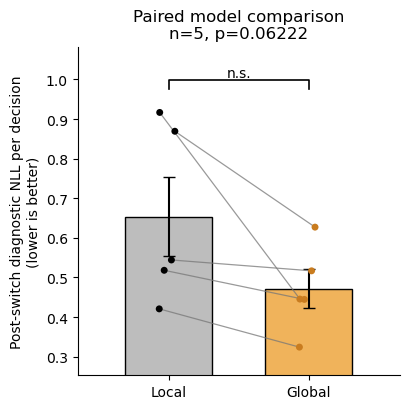

{'n_mice': 5, 'mean_difference': 0.1821199111914213, 'median_difference': 0.09654691844670604, 'p_value': 0.062219377806221936, 'alternative': 'two-sided'}


In [58]:
fig, ax = plt.subplots(
    figsize=(4.2, 4.2)
)

ax, test_result = plot_paired_model_nll(
    results_df,
    use_diagnostic=True,
    alternative="two-sided",
    n_permutations=100_000,
    seed=0,
    ax=ax,
)

plt.show()
print(test_result)